In [236]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import seaborn as sns


from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score


from seaborn import set_style
set_style("whitegrid")

In [237]:
# Source - https://stackoverflow.com/a/50051542
# Posted by Aaron Brock, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-26, License - CC BY-SA 3.0

def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,    
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path, 
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [238]:
#Read in the new processed data
loc = '../data/schedule_data/processed_data/by_weekday/'

csv_file_names = [loc+file for file in os.listdir(loc) if file.startswith('schedule_data')]
list_of_dataframes = [read_csv(file) 
    for file in csv_file_names]
main_df = pd.concat(list_of_dataframes, ignore_index=True)

In [239]:
main_df.nunique()

date                                          353
No. of Veh                                     12
Service interval                                3
Run time (min)                                 24
Term time (min)                                12
Avg. spd (km/h)                                28
Time of Day (morning: 0-late evening: 4)*       5
Weekday=0/Sat=1/Sun=2                           3
RT dist (km)                                    2
Interruption                                    2
time period start                            1764
time period end                              1764
EB/WB                                           2
bunch                                         263
total delay                                  3473
gap                                           308
dtype: int64

In [240]:
cat_features = [
    #'Service interval',
    'EB/WB',
    'Interruption'
]

time_features = [
    'date',
    'Time of Day (morning: 0-late evening: 4)*',
    'Weekday=0/Sat=1/Sun=2' 

]
num_features = [
    #'No. of Veh',
    #'Run time (min)',
    #'Term time (min)',
    #'Avg. spd (km/h)',
    #'RT dist (km)',
    'bunch',
    'gap'
]
#other = [
#    'time period start',
#    'time period end'
#]
features = time_features + cat_features + num_features 
main_df = main_df[features + ['total delay']]

In [241]:
main_df.head()

,date,Time of Day (morning: 0-late evening: 4)*,Weekday=0/Sat=1/Sun=2,EB/WB,Interruption,bunch,gap,total delay
0,2025-01-04,0,1,E,0,63,155,448.433333
1,2025-01-04,0,1,W,0,7,13,67.216667
2,2025-01-11,0,1,E,0,41,97,3191.800000
3,2025-01-11,0,1,W,0,34,38,820.566667
4,2025-01-18,0,1,E,0,3,27,340.916667


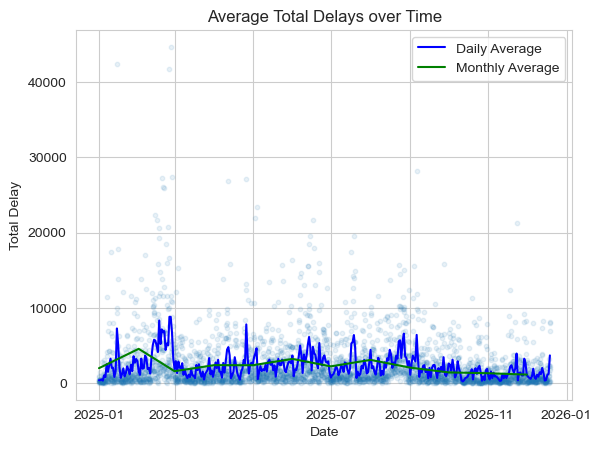

In [242]:
# Lets look at the average total delay for each day and for each month to check for seasonal trends 
plt.scatter(main_df['date'], main_df['total delay'], alpha=0.1, s=10)

# daily average
daily_avg = (
    main_df
    .groupby('date')['total delay']
    .mean()
    .reset_index()
)

plt.plot(
    daily_avg['date'],
    daily_avg['total delay'],
    color='blue',
    label="Daily Average"
)

# monthly average
monthly_avg = (
    main_df
    .assign(month=main_df['date'].dt.to_period('M'))
    .groupby('month', as_index=False)['total delay']
    .mean()
)

monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

plt.plot(
    monthly_avg['month'],
    monthly_avg['total delay'],
    color='green',
    label="Monthly Average"
)


plt.xlabel("Date")
plt.ylabel("Total Delay")
plt.title("Average Total Delays over Time")
plt.legend()

plt.show()

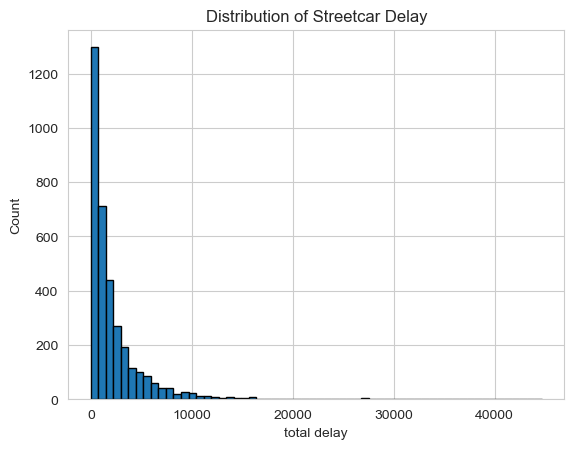

In [243]:
# Lets look at histograms for the target (total delay) and then for each of the numerical features
plt.hist(main_df['total delay'], bins=60, edgecolor='black')
plt.title("Distribution of Streetcar Delay")
plt.xlabel("total delay")
plt.ylabel("Count")
plt.show()

## Based on this distribution, it looks like a lot of the delays are pretty short 

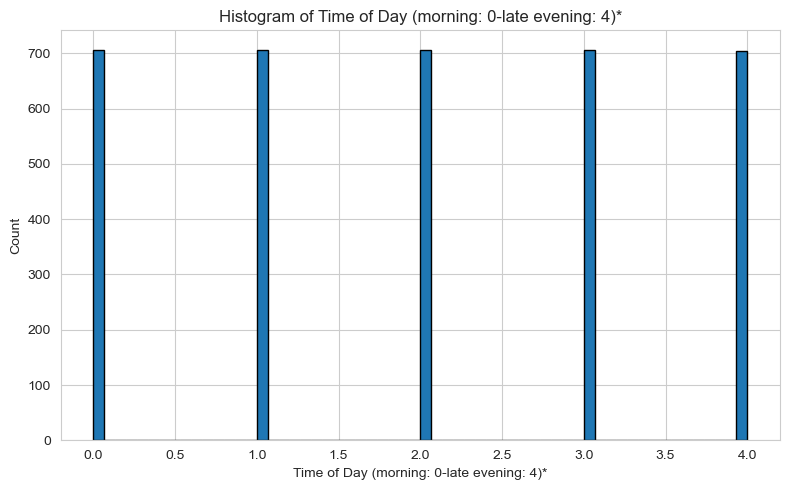

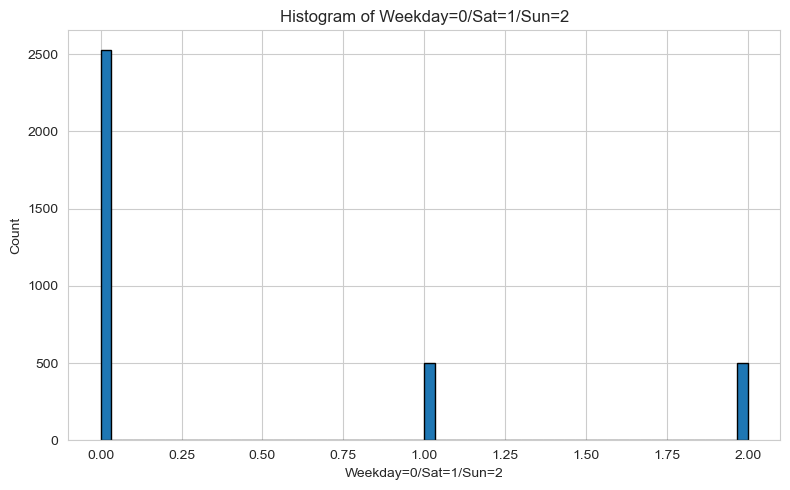

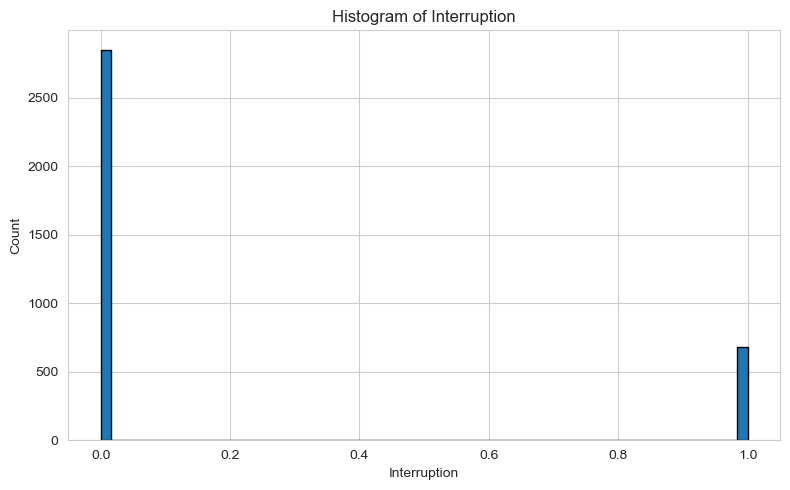

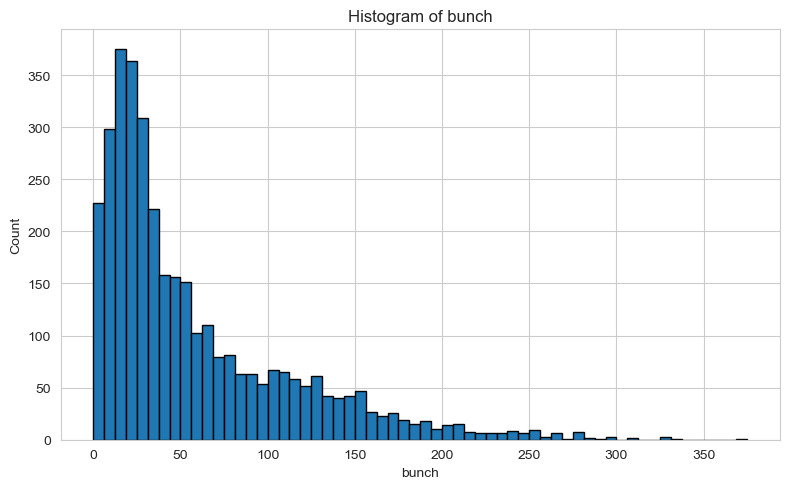

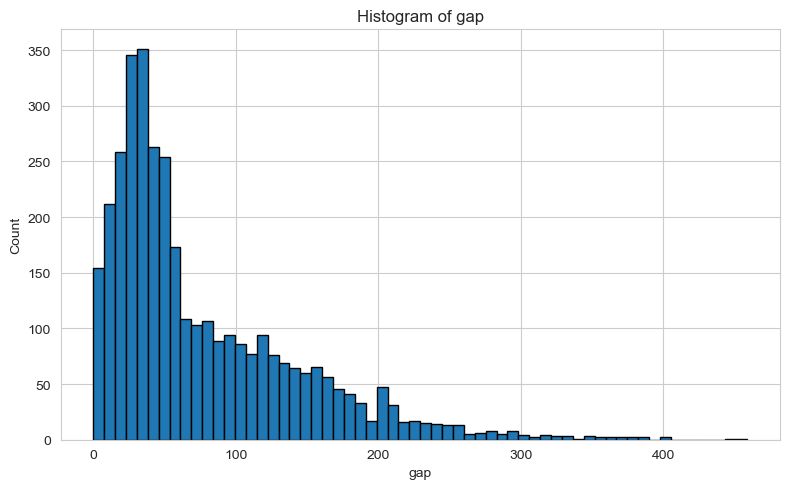

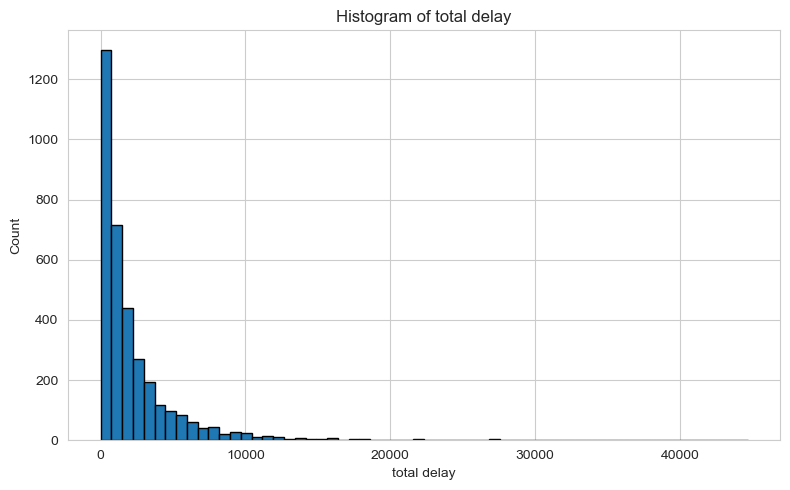

In [244]:
numeric_df = main_df.select_dtypes(include='number')

for col in numeric_df:
    plt.figure(figsize=(8, 5))
    plt.hist(main_df[col], bins=60, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    plt.close()

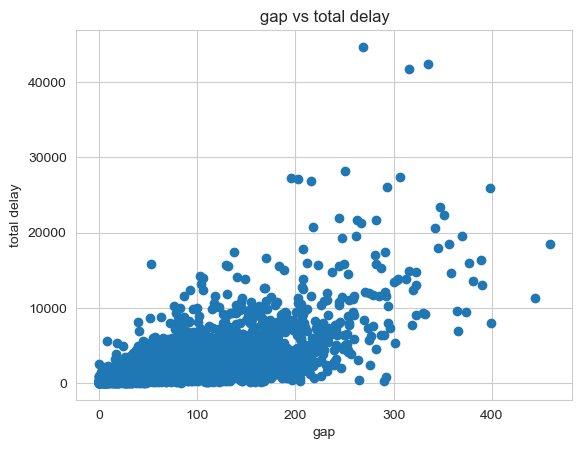

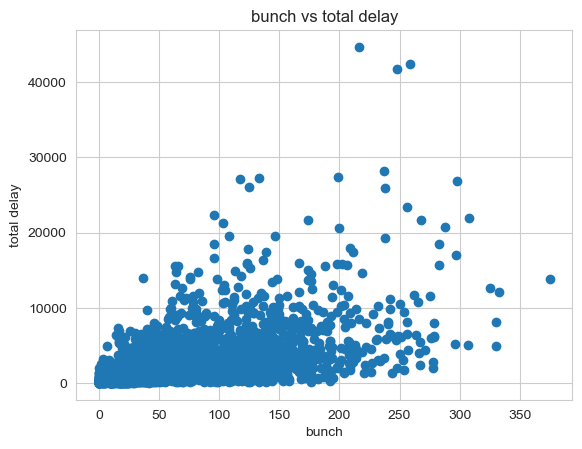

In [245]:
# Lets look at the gap vs total delay first 
plt.scatter(main_df['gap'], main_df['total delay'])
plt.xlabel("gap")
plt.ylabel("total delay")
plt.title("gap vs total delay")
plt.show()

plt.scatter(main_df['bunch'], main_df['total delay'])
plt.xlabel("bunch")
plt.ylabel("total delay")
plt.title("bunch vs total delay")
plt.show()

In [246]:
main_df["gap_group"] = pd.qcut(
    main_df["gap"],
    2,
    labels=["low gap", "high gap"]
)

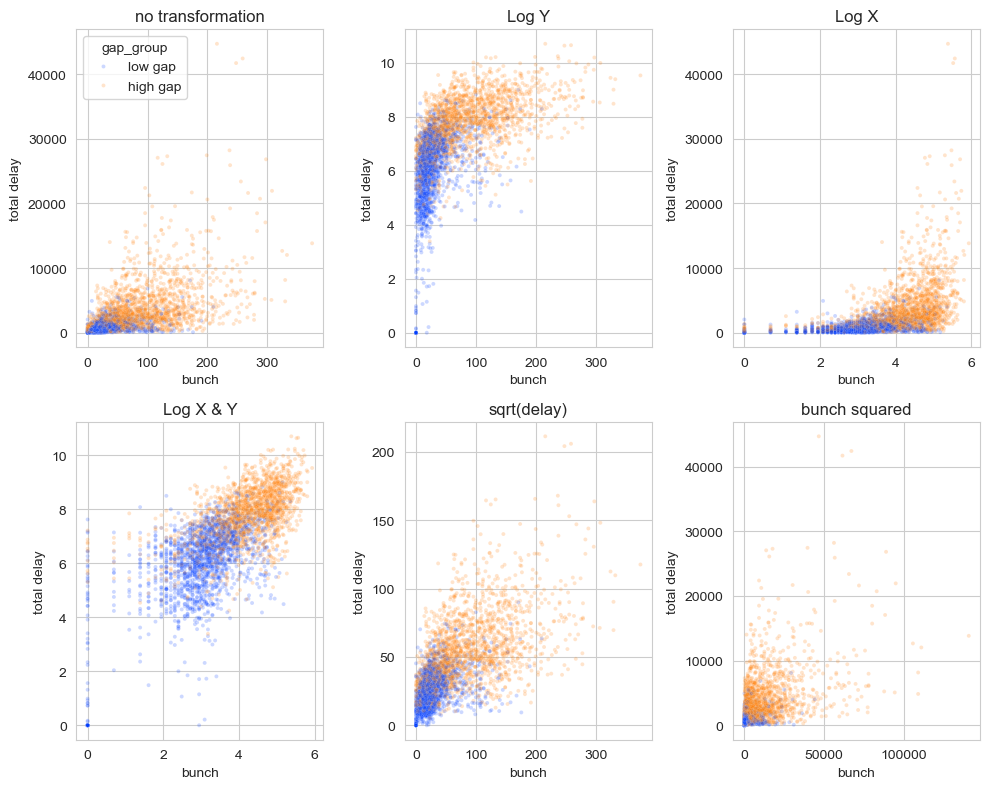

In [247]:
# Lets look at bunching vs total delay colored by gap_group with different transfolmations applied to the axes 
fig, axes = plt.subplots(2,3, figsize=(10,8))
color = "gap_group"
# no transformation
sns.scatterplot(
    data=main_df,
    x="bunch",
    y="total delay",
    hue=color,
    palette="bright",
    alpha=0.2,
    s=8,
    ax=axes[0,0],
    legend=True
)
axes[0,0].set_title("no transformation")

# Log Y
sns.scatterplot(
    data=main_df,
    x="bunch",
    y=np.log1p(main_df["total delay"]),
    hue=color,
    palette="bright",
    alpha=0.2,
    s=8,
    ax=axes[0,1],
    legend=False
)
axes[0,1].set_title("Log Y")

# Log X
sns.scatterplot(
    data=main_df,
    x=np.log1p(main_df["bunch"]),
    y="total delay",
    hue=color,
    palette="bright",
    alpha=0.2,
    s=8,
    ax=axes[0,2],
    legend=False
)

axes[0,2].set_title("Log X")

# Log X and Y
sns.scatterplot(
    data=main_df,
    x=np.log1p(main_df["bunch"]),
    y=np.log1p(main_df["total delay"]),
    hue=color,
    palette="bright",
    alpha=0.2,
    s=8,
    ax=axes[1,0],
    legend=False
)

axes[1,0].set_title("Log X & Y")

# Square root Y
sns.scatterplot(
    data=main_df, 
    x="bunch",
    y=np.sqrt(main_df["total delay"]),
    hue=color, 
    palette="bright",
    alpha=0.2,
    s=8,
    ax=axes[1,1],
    legend=False
)
axes[1,1].set_title("sqrt(delay)")

# Squared X
sns.scatterplot(
    data=main_df,
    x=main_df["bunch"]**2,
    y="total delay",
    hue=color, 
    palette="bright",
    alpha=0.2,
    s=8,
    ax=axes[1,2],
    legend=False
)
axes[1,2].set_title("bunch squared")

plt.tight_layout()
plt.show()

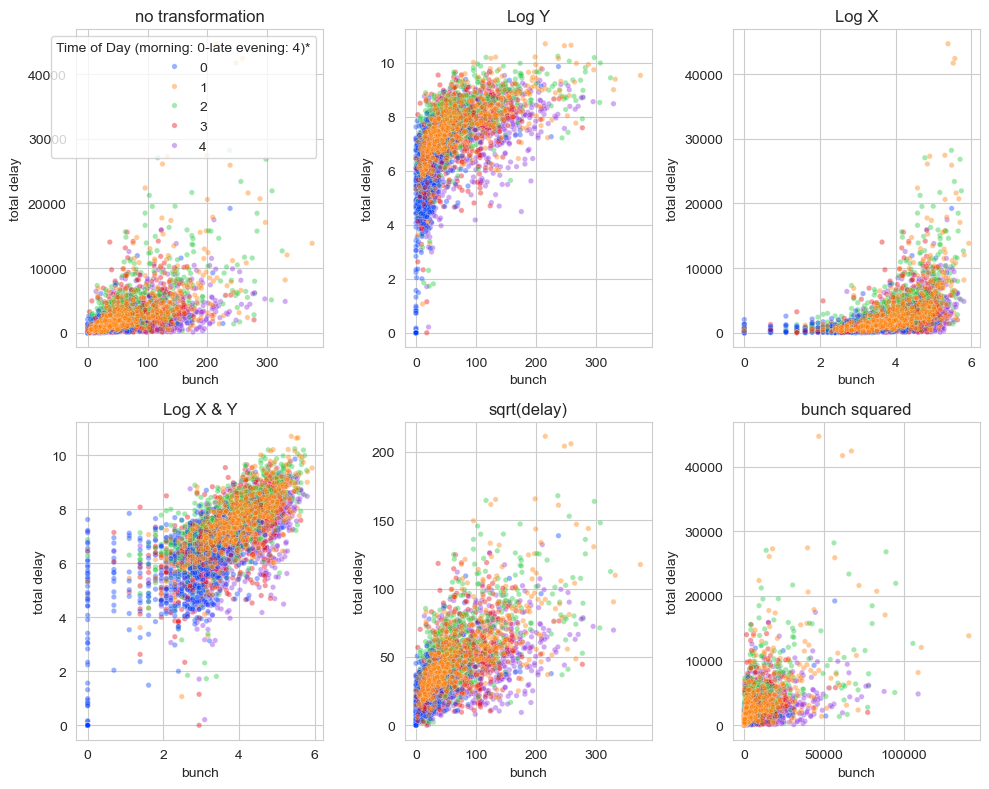

In [248]:
# Lets look at bunching vs total delay colored by gap_group with different transfolmations applied to the axes 
fig, axes = plt.subplots(2,3, figsize=(10,8))
color = "Time of Day (morning: 0-late evening: 4)*"
# no transformation
sns.scatterplot(
    data=main_df,
    x="bunch",
    y="total delay",
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[0,0],
    legend=True
)
axes[0,0].set_title("no transformation")

# Log Y
sns.scatterplot(
    data=main_df,
    x="bunch",
    y=np.log1p(main_df["total delay"]),
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[0,1],
    legend=False
)
axes[0,1].set_title("Log Y")

# Log X
sns.scatterplot(
    data=main_df,
    x=np.log1p(main_df["bunch"]),
    y="total delay",
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[0,2],
    legend=False
)

axes[0,2].set_title("Log X")

# Log X and Y
sns.scatterplot(
    data=main_df,
    x=np.log1p(main_df["bunch"]),
    y=np.log1p(main_df["total delay"]),
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[1,0],
    legend=False
)

axes[1,0].set_title("Log X & Y")

# Square root Y
sns.scatterplot(
    data=main_df, 
    x="bunch",
    y=np.sqrt(main_df["total delay"]),
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[1,1],
    legend=False
)
axes[1,1].set_title("sqrt(delay)")

# Squared X
sns.scatterplot(
    data=main_df,
    x=main_df["bunch"]**2,
    y="total delay",
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[1,2],
    legend=False
)
axes[1,2].set_title("bunch squared")

plt.tight_layout()
plt.show()

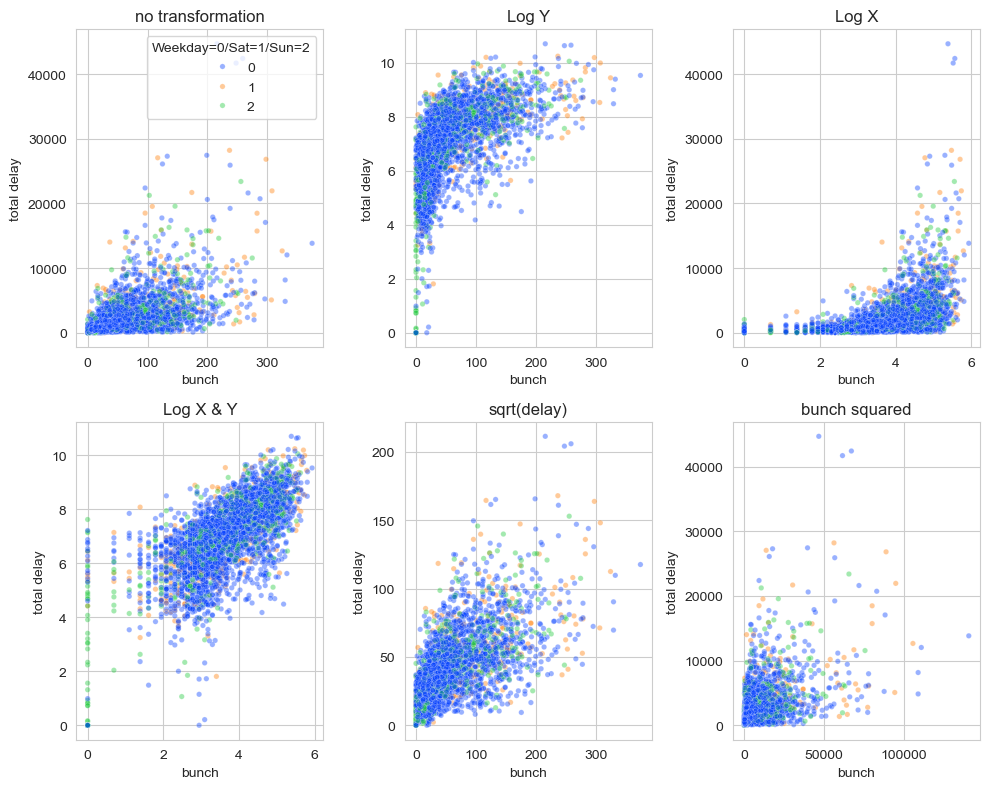

In [249]:
# Lets look at bunching vs total delay colored by gap_group with different transfolmations applied to the axes 
fig, axes = plt.subplots(2,3, figsize=(10,8))
color = "Weekday=0/Sat=1/Sun=2"
# no transformation
sns.scatterplot(
    data=main_df,
    x="bunch",
    y="total delay",
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[0,0],
    legend=True
)
axes[0,0].set_title("no transformation")

# Log Y
sns.scatterplot(
    data=main_df,
    x="bunch",
    y=np.log1p(main_df["total delay"]),
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[0,1],
    legend=False
)
axes[0,1].set_title("Log Y")

# Log X
sns.scatterplot(
    data=main_df,
    x=np.log1p(main_df["bunch"]),
    y="total delay",
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[0,2],
    legend=False
)

axes[0,2].set_title("Log X")

# Log X and Y
sns.scatterplot(
    data=main_df,
    x=np.log1p(main_df["bunch"]),
    y=np.log1p(main_df["total delay"]),
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[1,0],
    legend=False
)

axes[1,0].set_title("Log X & Y")

# Square root Y
sns.scatterplot(
    data=main_df, 
    x="bunch",
    y=np.sqrt(main_df["total delay"]),
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[1,1],
    legend=False
)
axes[1,1].set_title("sqrt(delay)")

# Squared X
sns.scatterplot(
    data=main_df,
    x=main_df["bunch"]**2,
    y="total delay",
    hue=color, 
    palette="bright",
    alpha=0.4,
    s=15,
    ax=axes[1,2],
    legend=False
)
axes[1,2].set_title("bunch squared")

plt.tight_layout()
plt.show()

It looks like the best transformation to see a linear relationship is going to be modeled with log(bunch) and log(delay), raw(bunch) log(delay), raw(bunch) sqrt(delay), raw(bunch) raw(delay). So I will consider each of these 4 models. I will go ahead and add columns for each of the transformed features/targets.

In [250]:
main_df["log_bunch"] = np.log1p(main_df["bunch"])
main_df["log_delay"] = np.log1p(main_df["total delay"])
main_df["sqrt_delay"] = np.sqrt(main_df["total delay"])


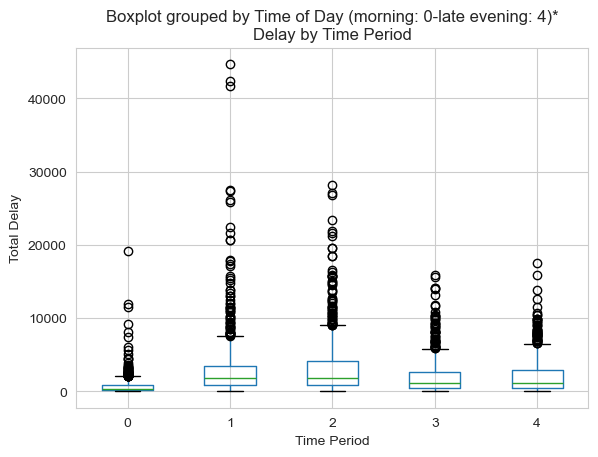

In [251]:
#Compare the total delay time across each time period
main_df.boxplot(column='total delay', by='Time of Day (morning: 0-late evening: 4)*')
plt.title("Delay by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Total Delay")
plt.show()

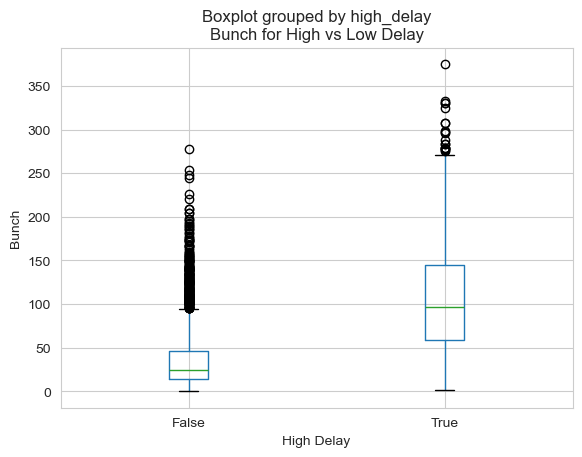

In [252]:
# Compare the values of gap for high delay times (greater than mean) vs low delay times
main_df['high_delay'] = main_df['total delay'] > main_df['total delay'].mean()

main_df.boxplot(column='bunch', by='high_delay')
plt.title("Bunch for High vs Low Delay")
plt.xlabel("High Delay")
plt.ylabel("Bunch")
plt.show()

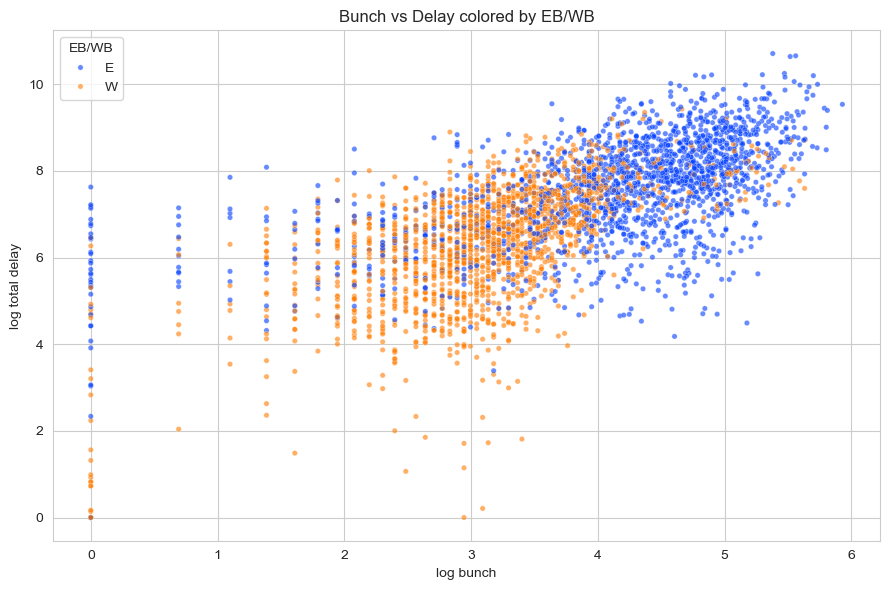

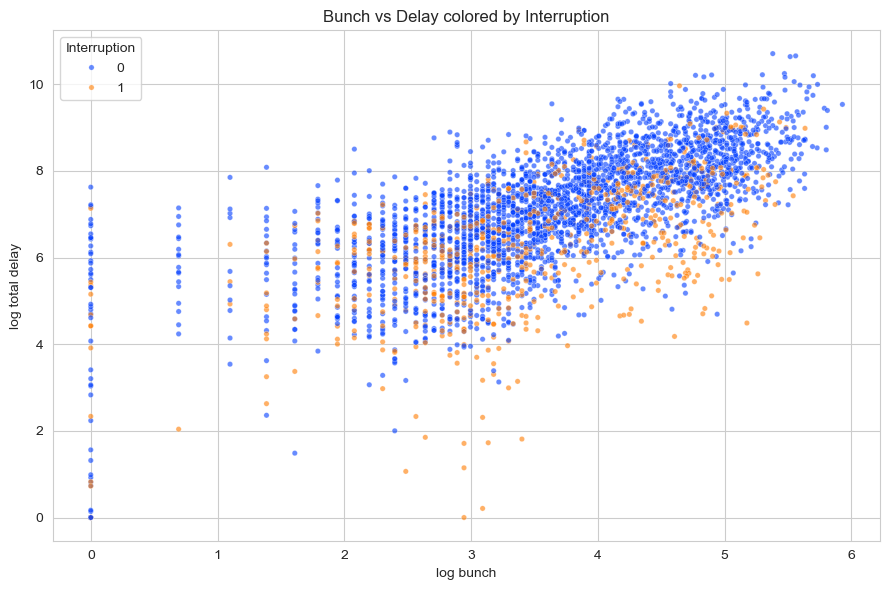

In [253]:
for hue_col in cat_features:
    plt.figure(figsize=(9,6))
    sns.scatterplot(
        data=main_df,
        x=main_df["log_bunch"],
        y=main_df["log_delay"],
        hue=hue_col,
        palette="bright",
        alpha=0.6,
        s=15
    )

    
    plt.title(f"Bunch vs Delay colored by {hue_col}")
    plt.xlabel("log bunch")
    plt.ylabel("log total delay")


    plt.tight_layout()
    plt.show()
    plt.close()

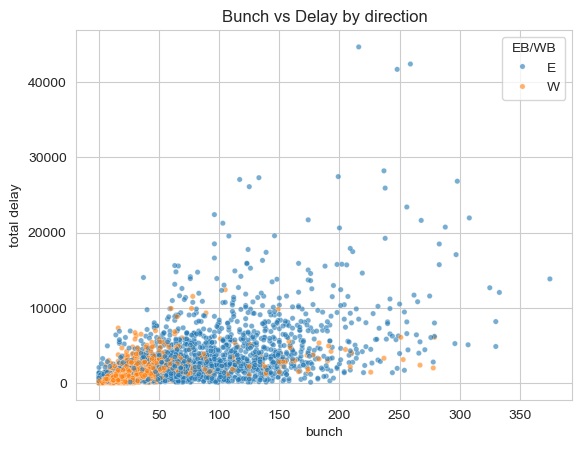

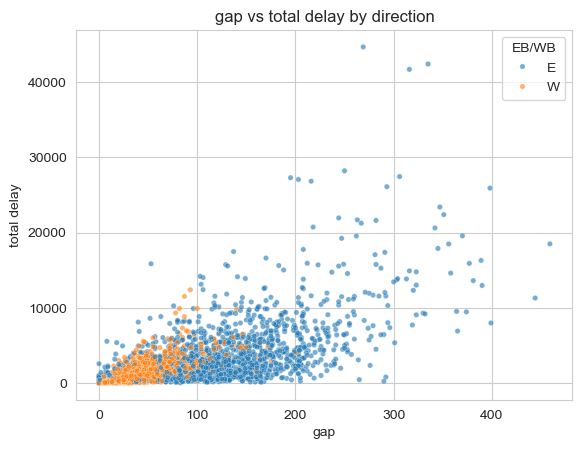

In [254]:
sns.scatterplot(
    data=main_df,
    x="bunch",
    y="total delay",
    hue='EB/WB',
    alpha=0.6,
    s = 15
)

plt.title("Bunch vs Delay by direction")
plt.show()


sns.scatterplot(
    data=main_df,
    x="gap",
    y="total delay",
    hue='EB/WB',
    alpha=0.6,
    s = 15
)

plt.title("gap vs total delay by direction")
plt.show()


In [255]:
main_df[features]

,date,Time of Day (morning: 0-late evening: 4)*,Weekday=0/Sat=1/Sun=2,EB/WB,Interruption,bunch,gap
0,2025-01-04,0,1,E,0,63,155
1,2025-01-04,0,1,W,0,7,13
2,2025-01-11,0,1,E,0,41,97
3,2025-01-11,0,1,W,0,34,38
4,2025-01-18,0,1,E,0,3,27
...,...,...,...,...,...,...,...
3523,2025-12-17,1,0,W,1,6,39
3524,2025-12-18,1,0,E,1,63,96
3525,2025-12-18,1,0,W,1,14,33
3526,2025-12-19,1,0,E,1,190,365


Now we will split the data based on the dates and then as a baseline model, we calculate the total delay time by taking the average delay time for the test data in a given time period. 

Then we will compare with linear models based on teh transformations described above with bunching and gapping as additional features. 

In [256]:
# Lets partition the data based on the date and use this to build our testing and training sets 

main_df["date"] = pd.to_datetime(main_df["date"])
time_period = 'Time of Day (morning: 0-late evening: 4)*'
weekday = 'Weekday=0/Sat=1/Sun=2'

# For the baseline, we will only use the time attributes as features and the target toal delay

cols = ["date", time_period, weekday, "total delay"]


dummy_df = main_df[cols].copy()
dummy_df = dummy_df.sort_values("date").reset_index(drop=True)

dates = dummy_df["date"].copy()
unique_dates = np.sort(dates.unique())

date_blocks = np.array_split(unique_dates, 6)

splits = []

for i in range(1, 6):
    train_dates = np.concatenate(date_blocks[:i])
    test_dates = date_blocks[i]

    train_df = dummy_df[dummy_df["date"].isin(train_dates)].copy()
    test_df = dummy_df[dummy_df["date"].isin(test_dates)].copy()

    splits.append((train_df, test_df))


In [257]:
# Baseline Model: Predict the total delay using the average training delay for the same time period 

maes = []
rmses = []
r2s = []

for fold, (train_df, test_df) in enumerate(splits,1):
    X_train = train_df[[time_period, weekday]].copy()
    X_test = test_df[[time_period, weekday]].copy()

    y_train = train_df["total delay"].copy()
    y_test = test_df["total delay"].copy()

# Temporary training data frame with features and target together
    temp_train = pd.concat(
        [X_train, y_train.rename("total delay")],
        axis=1
    )

# Calculate the average delay time for each time period

    mean_by_period = temp_train.groupby(time_period)["total delay"].mean()
    y_pred = X_test[time_period].map(mean_by_period)
    y_pred = y_pred.fillna(y_train.mean())

    mae = mean_absolute_error(y_test,y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)


    maes.append(mae)
    rmses.append(rmse)
    r2s.append(r2)

    print(
        f"Fold {fold}: "
        f"train_days={train_df['date'].nunique()}, "
        f"test_days={test_df['date'].nunique()}, "
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f},"
        f"R^2={r2:.2f}"
    )

print(
    f"For the baseline Model,"
    f"Average performance across folds:,"
    f"Mean MAE  = {np.mean(maes):.2f},"
    f"Mean RMSE = {np.mean(rmses):.2f},"
    f"Mean R^2 = {np.mean(r2s):.2f}"
)

Fold 1: train_days=59, test_days=59, MAE=2329.94, RMSE=3185.60,R^2=-0.38
Fold 2: train_days=118, test_days=59, MAE=1951.42, RMSE=3179.45,R^2=0.10
Fold 3: train_days=177, test_days=59, MAE=1982.00, RMSE=2801.96,R^2=-0.02
Fold 4: train_days=236, test_days=59, MAE=1932.71, RMSE=2688.84,R^2=-0.00
Fold 5: train_days=295, test_days=58, MAE=1776.89, RMSE=2196.34,R^2=-0.41
For the baseline Model,Average performance across folds:,Mean MAE  = 1994.59,Mean RMSE = 2810.44,Mean R^2 = -0.14
